# Mushroom comparison, error analysis and threshold evaluation

**Contribution owner: Muneeb Shakoor - integration, baseline reproduction, AutoML and error analysis (tasks 13, 15, 18, 24).**
Builds on Viviana Pajic's Mushroom exploration/evaluation (tasks 8/11) and the shared
AI-assisted starter maintained by Tomislav Novosel. Codex implemented and executed
this work at Muneeb's request on 8-9 October 2026. Muneeb selected the scope and
preservation requirements; this does not claim independent human authorship or
completed human code review. See [AI assistance](../docs/AI_USE.md) and
[reproduction and decisions](../docs/MUSHROOM_WORKFLOW.md).

Use Python 3.11 with `requirements-pycaret.lock.txt` for the recorded environment.

Tasks 13/15/18/24 form a completed development checkpoint. Model hyperparameter
tuning, AWS and final-test evaluation remain outside this checkpoint. The 1,000
reserved test rows are never supplied to any model here.


## Verify and collect the common results

Every row below uses the same dataset, ten inputs, 4,000 development rows, repeated
five-fold splits and library environment. Imputation/encoding occur within folds;
numeric scaling is added only for LR. AP is average precision, not trapezoidal
PR-AUC. Fold spread is not a confidence interval. Historical 60/20/20 and PyCaret
screening scores are deliberately excluded from this common leaderboard.


In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
while not (ROOT / 'src/mushrooms.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open the notebook inside the repository.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import json
import pandas as pd
from mushroom_workflow import REPORTS, PROCESSED
from mushroom_workflow import load_development, contract
X_dev, y_dev, _ = load_development()
comparison = pd.read_csv(REPORTS / 'comparison.csv')
for run in ['baseline_run.json', 'candidates_run.json']:
    assert json.loads((REPORTS / run).read_text())['contract'] == contract(X_dev, y_dev)
assert comparison.fold_fingerprint.nunique() == 1
display(comparison[['model', 'cv_average_precision', 'cv_average_precision_std',
                    'cv_roc_auc', 'train_average_precision', 'mean_fit_seconds',
                    'oof_poison_recall', 'oof_poison_precision', 'oof_f1']].round(6))


,model,cv_average_precision,cv_average_precision_std,cv_roc_auc,train_average_precision,mean_fit_seconds,oof_poison_recall,oof_poison_precision,oof_f1
0,random_forest,0.783075,0.008699,0.833420,0.950684,0.520128,0.520792,0.853896,0.646986
1,hist_gradient_boosting,0.758460,0.010047,0.812080,0.879463,0.220471,0.536634,0.815446,0.647293
2,extra_trees,0.754268,0.012941,0.804034,0.921481,0.351862,0.482508,0.844111,0.614028
3,logistic_regression,0.630651,0.010340,0.689445,0.653796,0.041113,0.345875,0.728790,0.469114
4,majority_baseline,0.378750,0.000000,0.500000,0.378750,0.015551,0.000000,0.000000,0.000000


## Complexity, strengths and limits

| Model | Configuration | Why include it | Main limitation |
|---|---|---|---|
| Majority dummy | Always the majority training class | Minimum reference | Misses every poisonous example at 0.5 |
| Logistic regression | Default regularization, 3,000 iteration cap | Simple additive model | Limited interactions; weak AP here |
| Random forest | 150 trees, minimum leaf 3 | Nonlinear interactions and bagging | Training/development gap; modest recall at 0.5 |
| Extra Trees | 150 trees, minimum leaf 3 | More randomized splits | Lower AP than RF in this experiment |
| Histogram boosting | 100 iterations, 15 leaves, L2=1 | Sequential nonlinear corrections | Lower AP here; needs bounded tuning before a final conclusion |

Recorded fit times measure fitting only, on this machine. They are descriptive;
they are not a hardware-controlled benchmark. These are initial settings, not
the best possible settings for each algorithm.


## Confusion matrices at the shared reference threshold 0.5

Poisonous is class 1. Rows are true classes; columns are predicted classes.
A false negative means a **poisonous mushroom predicted edible**. These matrices
use the mean of two held-out development probabilities per row, as in notebook 02.
They describe this reference classifier and are not independent final-test results.


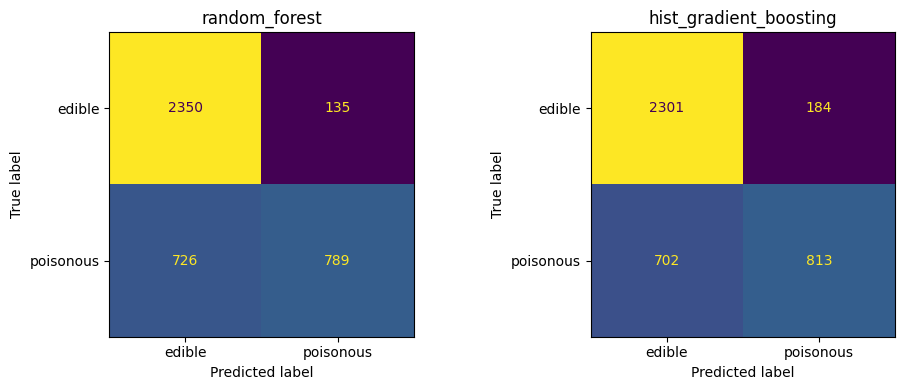

,model,threshold,tn,fp,fn,tp,rows
0,random_forest,0.5,2350,135,726,789,4000
1,hist_gradient_boosting,0.5,2301,184,702,813,4000


In [2]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
confusion_rows = []
for ax, model in zip(axes, ['random_forest', 'hist_gradient_boosting']):
    row = comparison.set_index('model').loc[model]
    matrix = [[int(row.oof_tn), int(row.oof_fp)], [int(row.oof_fn), int(row.oof_tp)]]
    ConfusionMatrixDisplay(np.array(matrix), display_labels=['edible', 'poisonous']).plot(ax=ax, colorbar=False)
    ax.set_title(model)
    confusion_rows.append({'model': model, 'threshold': .5, 'tn': matrix[0][0], 'fp': matrix[0][1],
                           'fn': matrix[1][0], 'tp': matrix[1][1], 'rows': sum(map(sum, matrix))})
plt.tight_layout()
# Embed explicitly: the first pyplot figure can otherwise become text-only
# with this pinned Matplotlib/IPython combination in a fresh kernel.
import io
from IPython.display import Image
image_buffer = io.BytesIO()
fig.savefig(image_buffer, format='png', bbox_inches='tight')
plt.close(fig)
display(Image(data=image_buffer.getvalue()))
confusion = pd.DataFrame(confusion_rows)
confusion.to_csv(REPORTS / 'error_confusion.csv', index=False)
display(confusion)


## Error rates by missing-feature count

Inspect RF and boosting, the two strongest AP candidates. At fixed threshold 0.5,
report sample sizes, poisonous/edible denominators, false-negative and false-positive
counts. An association with missingness is descriptive, not proof that missingness
caused the errors. Scores are not calibrated real-world confidence.


In [3]:
slice_rows = []
examples = []
for model in ['random_forest', 'hist_gradient_boosting']:
    predictions = pd.read_csv(PROCESSED / f'{model}_oof.csv').set_index('source_row').loc[X_dev.index]
    assert predictions.label.tolist() == y_dev.tolist()
    predictions['predicted'] = (predictions.poison_probability >= .5).astype(int)
    predictions['missing_group'] = pd.cut(predictions.missing_feature_count, [-1, 2, 4, 10], labels=['0-2', '3-4', '5-10'])
    for group, part in predictions.groupby('missing_group', observed=False):
        positive = part.label.eq(1)
        negative = part.label.eq(0)
        fn = int((positive & part.predicted.eq(0)).sum())
        fp = int((negative & part.predicted.eq(1)).sum())
        slice_rows.append({'model': model, 'missing_features': str(group), 'n': len(part),
                          'poisonous_n': int(positive.sum()), 'edible_n': int(negative.sum()),
                          'false_negatives': fn, 'false_positives': fp,
                          'false_negative_rate': fn / positive.sum() if positive.any() else None,
                          'false_positive_rate': fp / negative.sum() if negative.any() else None})
    false_negatives = predictions.loc[predictions.label.eq(1) & predictions.predicted.eq(0)].nsmallest(3, 'poison_probability')
    false_positives = predictions.loc[predictions.label.eq(0) & predictions.predicted.eq(1)].nlargest(3, 'poison_probability')
    for kind, part in [('false_negative', false_negatives), ('false_positive', false_positives)]:
        examples.append(part.drop(columns='missing_group').join(X_dev).assign(model=model, error_type=kind))
slices = pd.DataFrame(slice_rows)
slices.to_csv(REPORTS / 'error_slices.csv', index=False)
error_examples = pd.concat(examples).rename_axis('source_row').reset_index()
error_examples.to_csv(REPORTS / 'error_examples.csv', index=False)
display(slices.round(4))
display(error_examples[['model', 'error_type', 'source_row', 'label', 'poison_probability', 'missing_feature_count']])


,model,missing_features,n,poisonous_n,edible_n,false_negatives,false_positives,false_negative_rate,false_positive_rate
0,random_forest,0-2,1279,501,778,173,42,0.3453,0.0540
1,random_forest,3-4,2243,853,1390,444,88,0.5205,0.0633
2,random_forest,5-10,478,161,317,109,5,0.6770,0.0158
3,hist_gradient_boosting,0-2,1279,501,778,187,58,0.3733,0.0746
4,hist_gradient_boosting,3-4,2243,853,1390,413,110,0.4842,0.0791
5,hist_gradient_boosting,5-10,478,161,317,102,16,0.6335,0.0505


,model,error_type,source_row,label,poison_probability,missing_feature_count
0,random_forest,false_negative,642,1,0.052302,3
1,random_forest,false_negative,1420,1,0.082044,2
2,random_forest,false_negative,2860,1,0.090058,1
3,random_forest,false_positive,2946,0,0.952840,0
4,random_forest,false_positive,4538,0,0.935772,1
5,random_forest,false_positive,4962,0,0.933475,2
6,hist_gradient_boosting,false_negative,642,1,0.019971,3
7,hist_gradient_boosting,false_negative,59,1,0.040165,2
8,hist_gradient_boosting,false_negative,4319,1,0.056787,2
9,hist_gradient_boosting,false_positive,2946,0,0.970057,0


## What the errors show

RF misses 726 of 1,515 poisonous development rows at 0.5 (47.9%) and flags
135 of 2,485 edible rows (5.4%). Boosting misses 702 but flags 184 edible rows;
its slightly greater recall at this threshold does not make it the AP leader.

RF's false-negative rate rises from 34.5% in the 0-2 missing-feature group to
52.1% in the 3-4 group and 67.7% in the 5-10 group. These are class-conditional
rates with denominators above. The groups are descriptive and were not used to
choose separate thresholds. Missingness does not establish the cause of an error.

The source-row examples below are auditable development failures, not proof of
incorrect dataset labels. A low model score for a poisonous label is especially
concerning; it is not evidence that the label should be changed.


In [4]:
display(error_examples.loc[error_examples.error_type.eq('false_negative')])

,source_row,label,poison_probability,missing_feature_count,predicted,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,model,error_type
0,642,1,0.052302,3,0,18.95,22.98,18.71,NaN,w,m,NaN,m,p,NaN,random_forest,false_negative
1,1420,1,0.082044,2,0,NaN,6.44,10.03,NaN,w,l,w,f,f,s,random_forest,false_negative
2,2860,1,0.090058,1,0,6.05,7.91,10.66,NaN,w,l,a,f,x,s,random_forest,false_negative
6,642,1,0.019971,3,0,18.95,22.98,18.71,NaN,w,m,NaN,m,p,NaN,hist_gradient_boosting,false_negative
7,59,1,0.040165,2,0,9.06,7.03,35.75,NaN,w,m,s,f,f,NaN,hist_gradient_boosting,false_negative
8,4319,1,0.056787,2,0,5.11,12.30,10.39,NaN,w,NaN,u,f,x,s,hist_gradient_boosting,false_negative


## Choose and evaluate a threshold policy without reusing evaluation labels

Keep the fixed RF (150 trees, minimum leaf 3). Retain task 11's **90% recall target
as a provisional coursework preference**, since missing poisonous labels is an
important error. No supplied cost model or lecturer requirement establishes 90%
as sufficient. We show 80% and 95% alternatives for context, not as tested safety
standards.

Policy: choose the threshold with greatest specificity subject to calibration
recall at least 90%; break ties with the largest threshold. Classify as poisonous
when score **>= threshold**. This differs from the historical helper's
maximum-precision objective.

For each of five outer development folds, generate three-fold OOF probabilities
using only the outer training rows, choose a threshold there, refit the fixed RF
on those training rows, and evaluate the threshold on the untouched outer fold.
Preprocessing is fitted inside every inner and outer training pipeline. The
outer labels cannot influence that fold's threshold. This adds 20 fixed-model
fits and does not tune any model hyperparameters.

The following threshold experiment uses **one outer held-out score per row**.
The earlier baseline error table averages two scores per row, so the counts need
not match. Compare threshold policies below on the same outer scores.


In [5]:
from mushroom_error_analysis import run_error_analysis
threshold_run, threshold_folds, tradeoff = run_error_analysis()
display(threshold_folds[['fold', 'threshold', 'inner_calibration_recall', 'poison_recall',
                         'poison_precision', 'specificity', 'tn', 'fp', 'fn', 'tp']].round(6))
policy_comparison = pd.DataFrame([
    {'policy': 'Fixed 0.5 on the same outer scores', **threshold_run['fixed_0_5_same_outer_scores']},
    {'policy': 'Threshold selected within each outer training fold', **threshold_run['nested_policy_metrics']},
    {'policy': 'Single threshold selected on ALL OOF scores (apparent)', **threshold_run['selected_threshold_metrics_apparent']},
])
display(policy_comparison[['policy', 'poison_recall', 'poison_precision', 'specificity', 'f1', 'tn', 'fp', 'fn', 'tp']].round(6))
print('Selected provisional single development threshold:', threshold_run['selected_development_threshold'])


RF threshold policy: 5 outer development folds, 3 inner calibration folds; fixed model.


Selected development threshold=0.24692594; nested policy recall=0.892409


,fold,threshold,inner_calibration_recall,poison_recall,poison_precision,specificity,tn,fp,fn,tp
0,0,0.251563,0.900165,0.897690,0.520076,0.494970,246,251,31,272
1,1,0.245484,0.900165,0.904290,0.481547,0.406439,202,295,29,274
2,2,0.254586,0.900165,0.884488,0.479428,0.414487,206,291,35,268
3,3,0.256004,0.900165,0.881188,0.503774,0.470825,234,263,36,267
4,4,0.255953,0.900165,0.894389,0.508443,0.472837,235,262,32,271


,policy,poison_recall,poison_precision,specificity,f1,tn,fp,fn,tp
0,Fixed 0.5 on the same outer scores,0.525413,0.843220,0.940443,0.647418,2337,148,719,796
1,Threshold selected within each outer training ...,0.892409,0.498158,0.451911,0.639395,1123,1362,163,1352
2,Single threshold selected on ALL OOF scores (a...,0.900330,0.491354,0.431791,0.635749,1073,1412,151,1364


Selected provisional single development threshold: 0.2469259427573105


## Precision/recall trade-off and remaining failures

The grid and curve below use all outer OOF predictions. Values for a threshold
chosen using these same labels are **selection/descriptive estimates**. The
separate outer-fold policy row above is the evaluation of the selection procedure.
A final single threshold is selected from all these development OOF scores for a
later frozen-model decision; its independent performance remains unmeasured.


,selection,target_recall,threshold,poison_precision,poison_recall,specificity,fn,fp
0,fixed grid,NaN,0.000000,0.378750,1.000000,0.000000,0,2485
1,fixed grid,NaN,0.100000,0.383558,0.994719,0.025352,8,2422
2,fixed grid,NaN,0.200000,0.446368,0.953135,0.279276,71,1791
3,fixed grid,NaN,0.300000,0.571750,0.838944,0.616901,244,952
4,fixed grid,NaN,0.400000,0.730635,0.691089,0.844668,468,386
5,fixed grid,NaN,0.500000,0.843220,0.525413,0.940443,719,148
6,fixed grid,NaN,0.600000,0.888717,0.379538,0.971026,940,72
7,fixed grid,NaN,0.700000,0.914286,0.253465,0.985513,1131,36
8,fixed grid,NaN,0.800000,0.938326,0.140594,0.994366,1302,14
9,fixed grid,NaN,0.900000,0.853659,0.023102,0.997586,1480,6


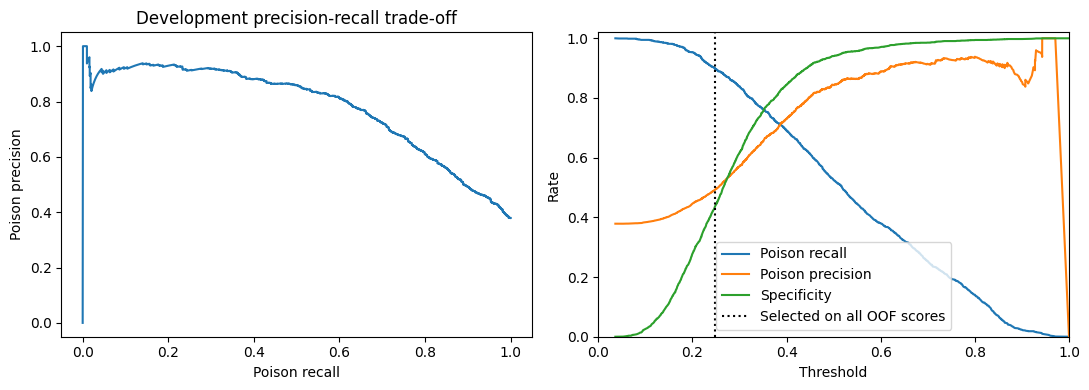

,model,policy,missing_features,n,poisonous_n,edible_n,false_negatives,false_positives,false_negative_rate,false_positive_rate
0,random_forest,nested recall policy,0-2,1279,501,778,48,379,0.0958,0.4871
1,random_forest,nested recall policy,3-4,2243,853,1390,92,796,0.1079,0.5727
2,random_forest,nested recall policy,5-10,478,161,317,23,187,0.1429,0.5899


,source_row,label,poison_probability,outer_fold,selected_threshold,policy_prediction,missing_feature_count,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface
0,642,1,0.036283,1,0.245484,0,3,18.95,22.98,18.71,NaN,w,m,NaN,m,p,NaN
1,2860,1,0.061620,3,0.256004,0,1,6.05,7.91,10.66,NaN,w,l,a,f,x,s
2,3060,1,0.080970,1,0.245484,0,3,9.46,NaN,19.31,NaN,b,d,a,f,f,NaN
3,4265,1,0.081035,3,0.256004,0,3,NaN,5.27,5.30,NaN,n,d,NaN,r,x,s
4,3875,1,0.081996,4,0.255953,0,5,NaN,NaN,20.71,NaN,f,l,s,f,NaN,NaN
5,573,1,0.085665,3,0.256004,0,5,NaN,7.31,NaN,NaN,w,NaN,a,f,NaN,s
6,4811,1,0.088032,3,0.256004,0,1,9.17,7.57,13.16,NaN,y,h,a,f,x,s
7,1420,1,0.089724,1,0.245484,0,2,NaN,6.44,10.03,NaN,w,l,w,f,f,s
8,4855,1,0.108709,2,0.254586,0,4,NaN,4.90,12.65,NaN,n,w,NaN,r,f,NaN
9,4319,1,0.110773,4,0.255953,0,2,5.11,12.30,10.39,NaN,w,NaN,u,f,x,s


In [6]:
display(tradeoff[['selection', 'target_recall', 'threshold', 'poison_precision', 'poison_recall',
                  'specificity', 'fn', 'fp']].round(6))
curve = pd.read_csv(REPORTS / 'threshold_curve.csv')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(curve.poison_recall, curve.poison_precision)
axes[0].set(xlabel='Poison recall', ylabel='Poison precision', title='Development precision-recall trade-off')
axes[1].plot(curve.threshold, curve.poison_recall, label='Poison recall')
axes[1].plot(curve.threshold, curve.poison_precision, label='Poison precision')
axes[1].plot(curve.threshold, curve.specificity, label='Specificity')
axes[1].axvline(threshold_run['selected_development_threshold'], color='black', linestyle=':', label='Selected on all OOF scores')
axes[1].set(xlabel='Threshold', ylabel='Rate', xlim=(0, 1), ylim=(0, 1.02))
axes[1].legend()
plt.tight_layout()
plt.show()
display(pd.read_csv(REPORTS / 'threshold_error_slices.csv').round(4))
display(pd.read_csv(REPORTS / 'threshold_false_negatives.csv'))


## Decision and limits

RF remains the AP leader among the four screened families. The provisional offline
policy prioritizes recall and accepts more false alarms on edible labels. The selected single development threshold is **0.24692594**. Separately evaluated
threshold selection reaches **89.24% recall, 49.82% precision and 45.19% specificity**
on outer development folds, with **163 false negatives and 1,362 false positives**.
Satisfying 90% on calibration predictions does **not** ensure 90% on held-out predictions. False negatives remain even under
this policy. The examples and missingness groups identify failures to discuss,
without inventing a biological explanation or deleting inconvenient rows.

The outer experiment separates threshold selection from evaluation, but RF and
preparation were already selected using development results. It is therefore
conditional on those earlier choices, not a fully nested estimate of the entire
model-selection process. Inner models also train on fewer rows, and score
calibration/distribution can change when fitting on all development data. Fold
spread is descriptive; no independent confidence or safety guarantee is claimed.

The existing local demo bundle remains at its provisional reference threshold
0.5. Task 24's selected threshold and policy are recorded separately in
`reports/mushrooms/threshold_run.json`; no deployment change is part of this task.
The earlier baseline contract describes the preceding 0.5 screening checkpoint.

**Completed here:** preparation, reproducible baseline evaluation, bounded PyCaret
screening, confusion matrices, auditable poisonous-as-edible errors, missingness
groups, threshold trade-offs and a separately evaluated development threshold policy.
**Outside this checkpoint:** tasks 20/21, final model selection, final-test evaluation,
AWS, Citi Bike and deployment. The reserved 1,000-row test remains unevaluated.
